<a href="https://colab.research.google.com/github/A-ghori/sklearn/blob/main/Power_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [49]:
df = pd.read_csv('/content/concrete_data.csv')
df.head(2)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89


In [50]:
df.shape #(1030 -> Smaples, 9-> features)

(1030, 9)

In [51]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [52]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [53]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]
X

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [55]:
## Applying Regression without any tranformation
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.627553179231485

In [56]:
## Cross checking with cross val score
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.4609940491662865)

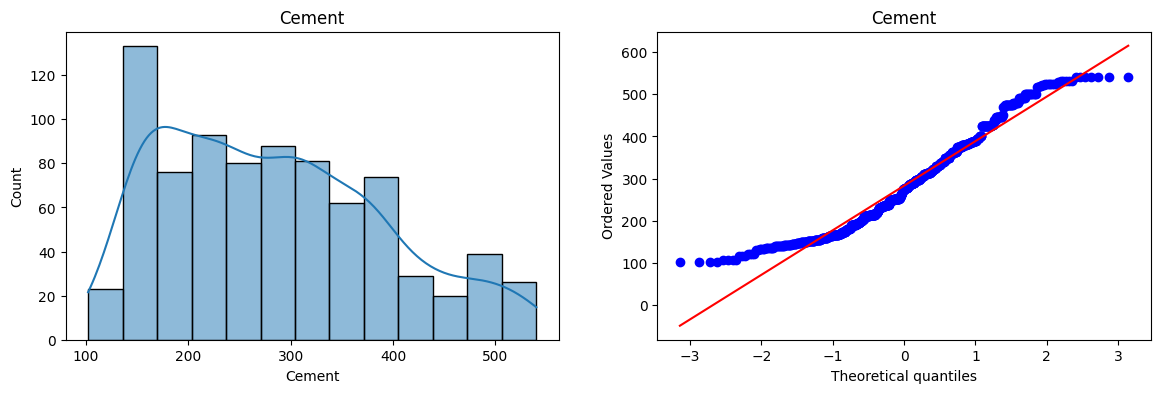

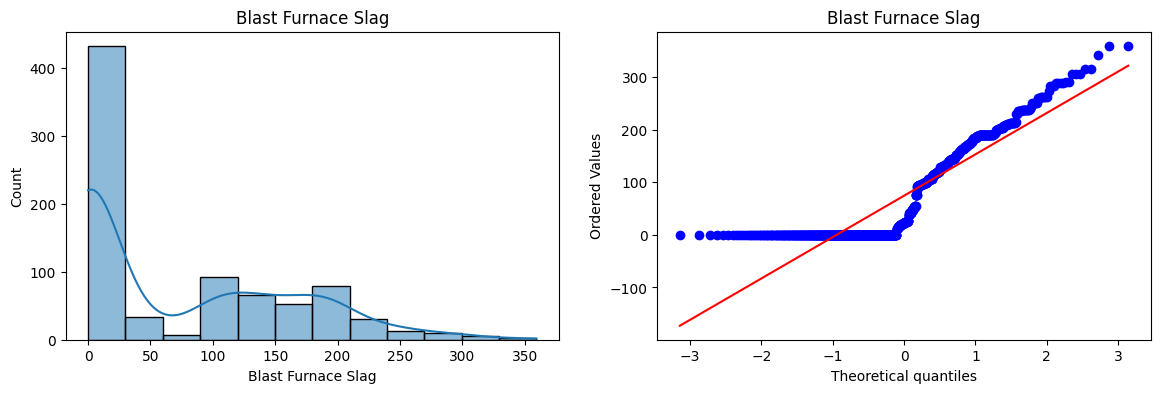

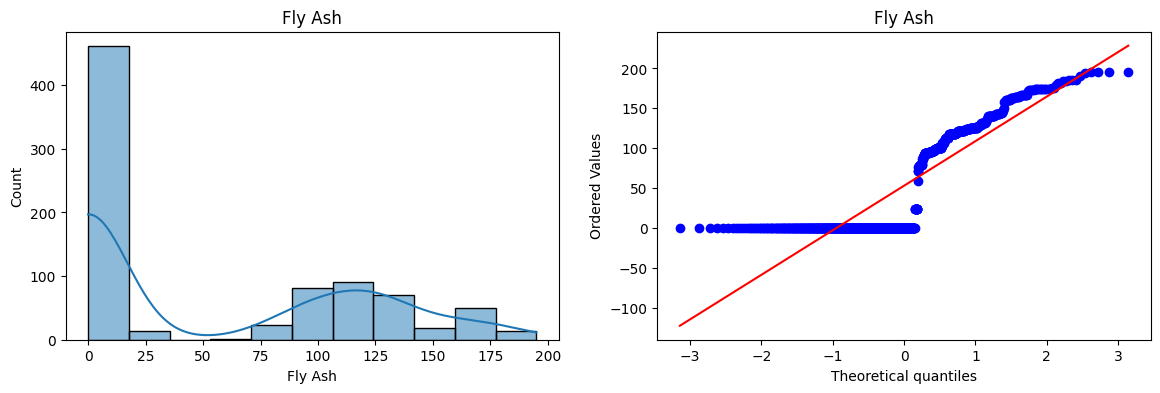

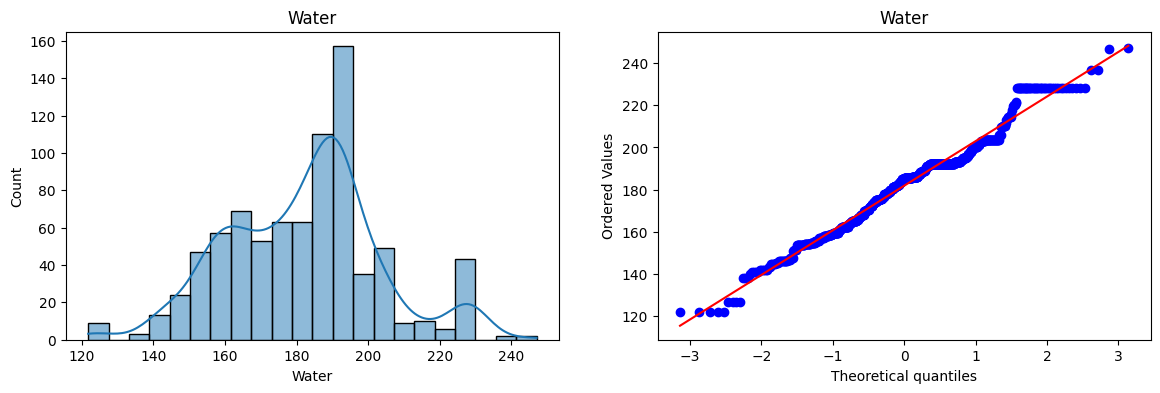

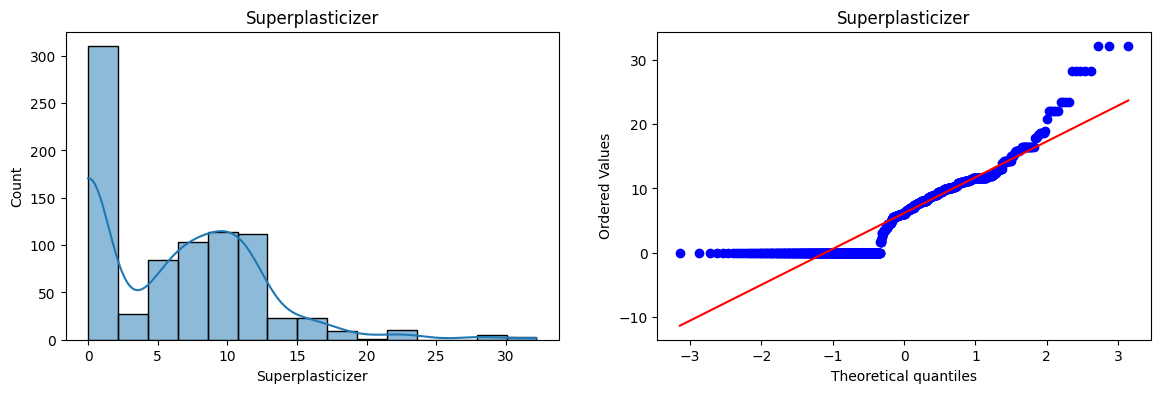

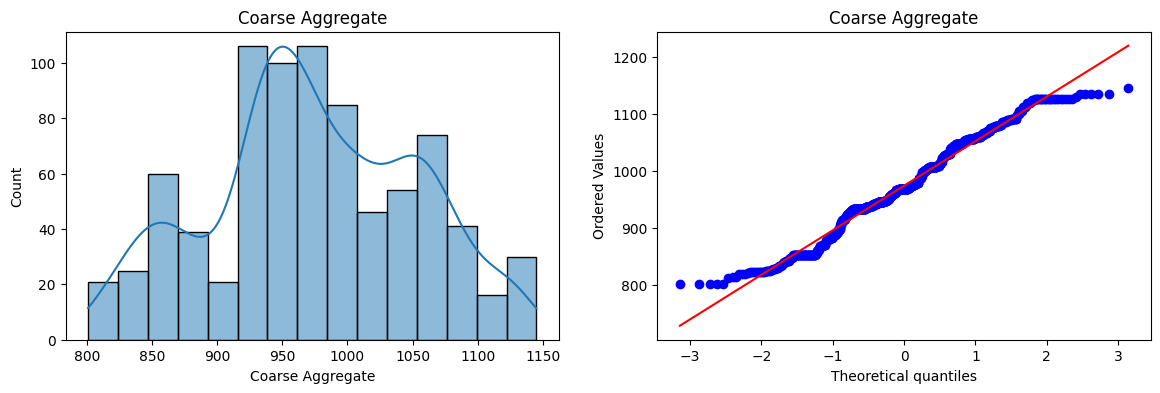

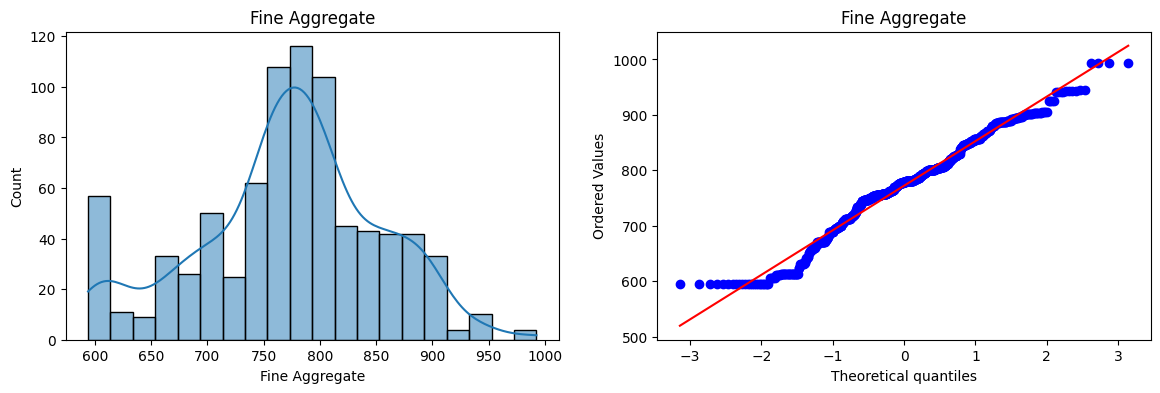

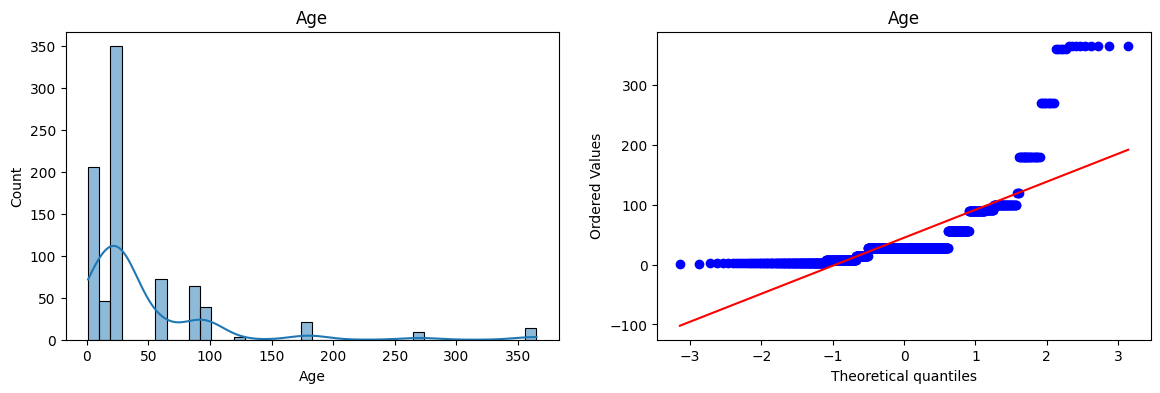

In [57]:
# Ploting the displots

for col in X_train.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(X_train[col],kde=True) #KDE = Kernel Density Estimate
  plt.title(col)

  plt.subplot(122)
  stats.probplot(X_train[col],dist="norm",plot=plt)
  plt.title(col)

  plt.show()

In [58]:
## Now applying Box-Cox Transform
pt = PowerTransformer(method='box-cox')

X_train_tranformed_Box_Cox = pt.fit_transform(X_train + 0.00001) ## Becausee Box-Cox works on greater than 0 values not negative if any cols contains -ve or less than 0 so it will add 0.00001 with this values
X_test_tranformed_Box_Cox = pt.transform(X_test + 0.00001)

pd.DataFrame({'cols':X_train.columns, 'box-cox_lambdas':pt.lambdas_}) ## suppose in cement feature has 540 value so initially (540)^0.177025 so this how it works same for others cols and apply the respective box-cox-lamdas


,cols,box-cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.027842
2,Fly Ash,-0.044554
3,Water,0.772681
4,Superplasticizer,0.113892
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066630


In [59]:
## Applying Regression with tranformation
lr = LinearRegression()
lr.fit(X_train_tranformed_Box_Cox, y_train)

y_pred = lr.predict(X_test_tranformed_Box_Cox)
r2_score(y_test, y_pred)
## 0.8054599358703155 why this accuracy increased because after box cox transform the skewd numerical features are more symmetric/normally-distributed so values will be more compressed and rearrance for the LinearRegression model thats why we get this kinda accuracy
# Linear Regression assume karta hai ki features aur target ke beech relationship reasonably linear ho.

0.8054599358703155

In [60]:
## Cross checking with cross val score
pt = PowerTransformer(method='box-cox')
X_train_tranformed_Box_Cox = pt.fit_transform(X_train + 0.00001)
lr = LinearRegression()
np.mean(cross_val_score(lr,X_train_tranformed_Box_Cox,y_train,scoring='r2',cv=10))

np.float64(0.7916132314231751)

In [61]:
print(type(X_test_tranformed_Box_Cox))

<class 'numpy.ndarray'>


In [62]:
## ok so convert numpy into dataframes
X_train_tranformed_Box_Cox = pd.DataFrame(
    X_train_tranformed_Box_Cox,
    columns=X_train.columns,
    index = X_train.index
)

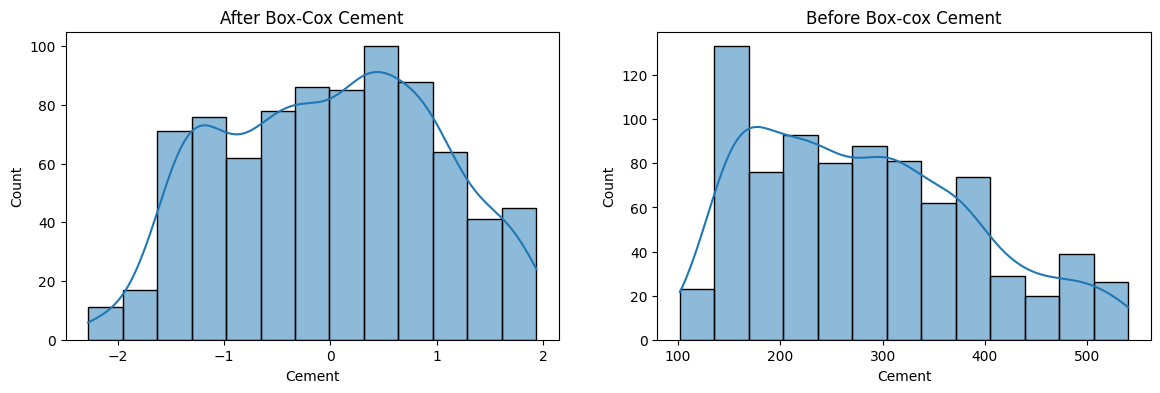

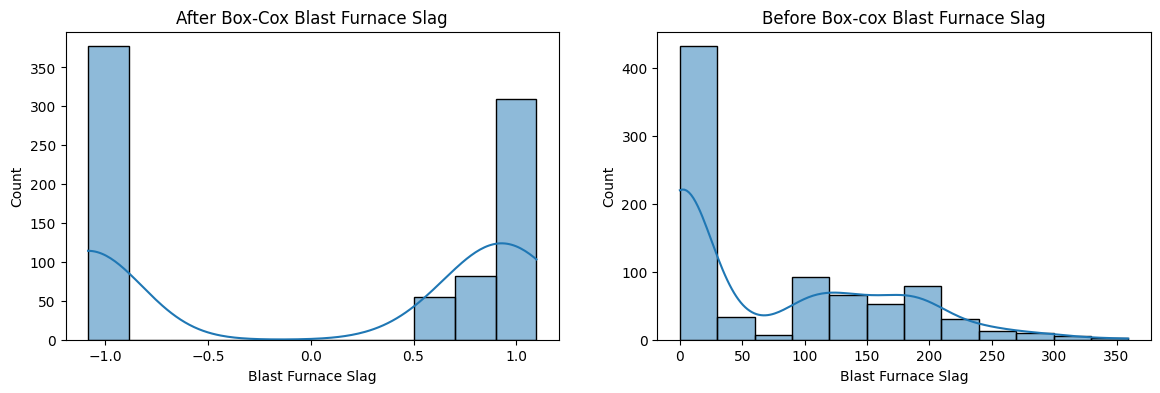

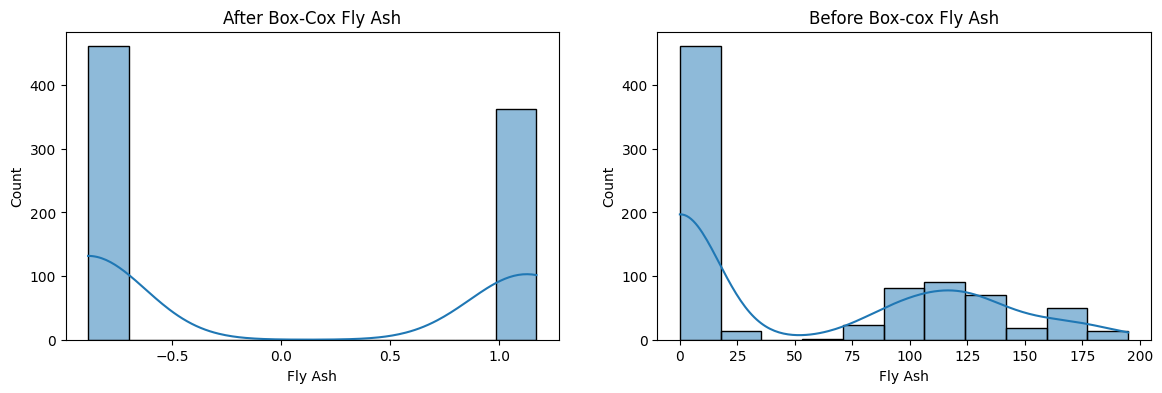

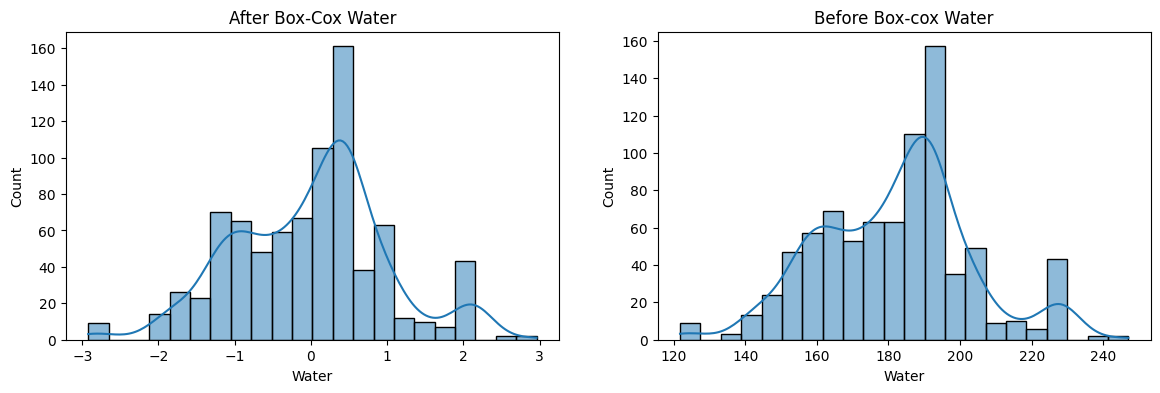

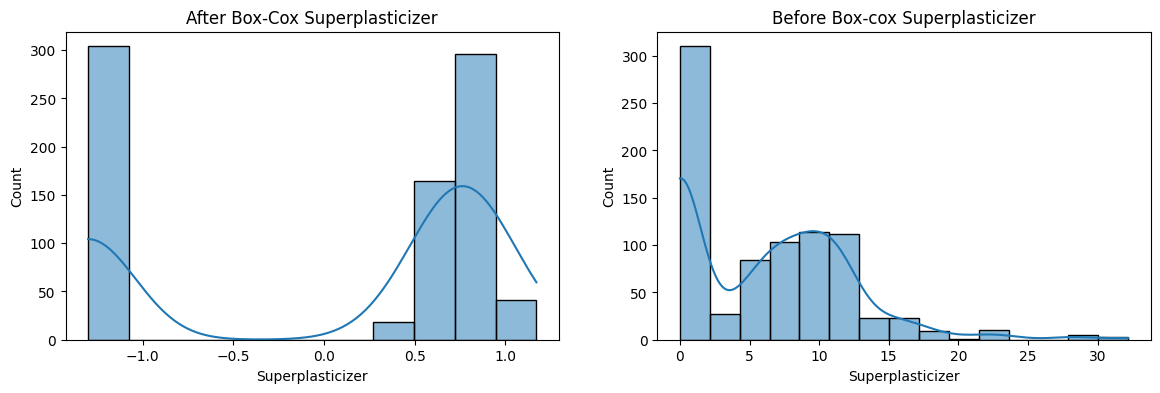

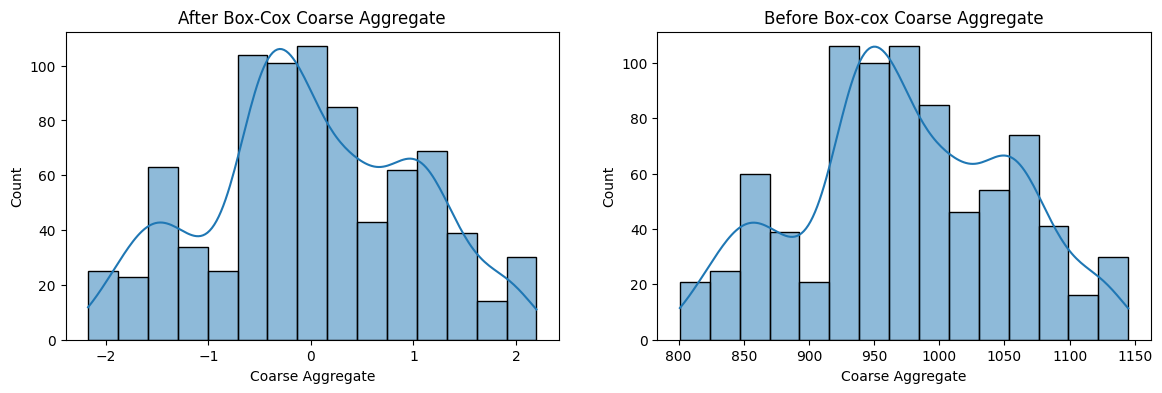

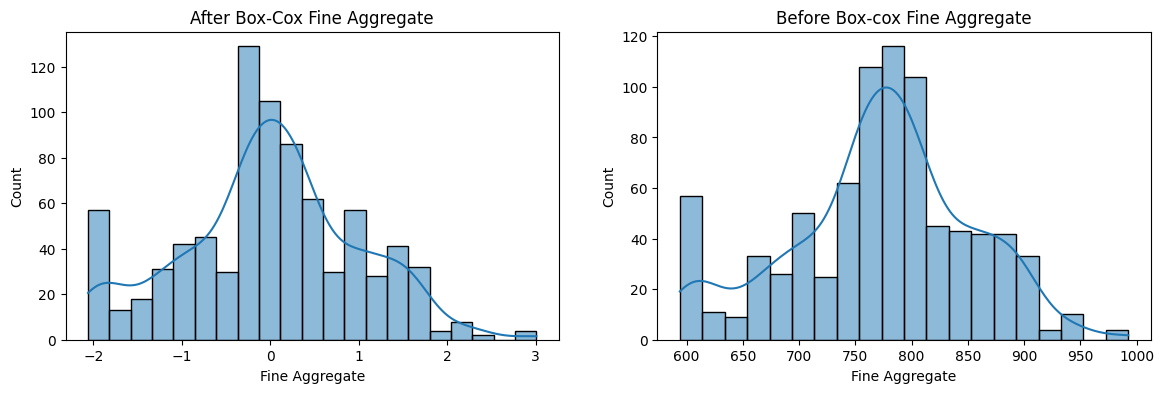

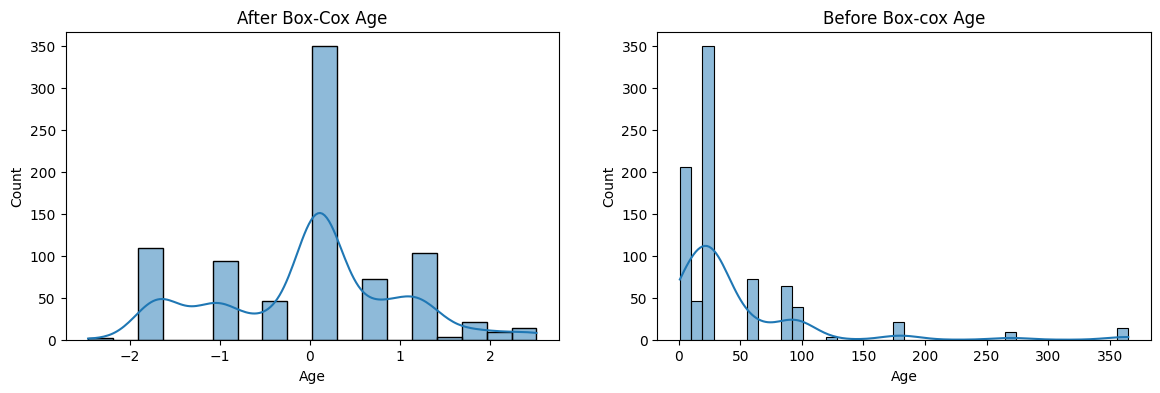

In [63]:
## Before and After Comparison for Box-Cox Plot

for col in X_train_tranformed_Box_Cox.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(121)
  sns.histplot(X_train_tranformed_Box_Cox[col],kde=True)
  plt.title(f"After Box-Cox {col}")

  plt.subplot(122)
  sns.histplot(X_train[col],kde=True)
  plt.title(f"Before Box-cox {col}")

  plt.show()


## Applying Yeo-Jhonson

In [64]:
pt1 = PowerTransformer()

X_train_Yeo_Jhonson = pt1.fit_transform(X_train)
X_test_Yeo_Jhonson = pt1.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_Yeo_Jhonson, y_train)
y_pred = lr.predict(X_test_Yeo_Jhonson)

print(r2_score(y_test, y_pred))
pd.DataFrame({'cols':X_train.columns, 'Yeo-Jhonson_Lamdas':pt1.lambdas_})



0.8161906509669064


,cols,Yeo-Jhonson_Lamdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [65]:
## Cross checking with cross val score
pt = PowerTransformer()
X_train_Yeo_Jhonson= pt.fit_transform(X_train)
lr = LinearRegression()
np.mean(cross_val_score(lr,X_train_Yeo_Jhonson,y_train,scoring='r2'))

np.float64(0.7941782178920658)

In [66]:
X_train_Yeo_Jhonson = pd.DataFrame(
    X_train_Yeo_Jhonson,
    columns = X_train.columns,
    index = X_train.index
)
print(type(X_train_Yeo_Jhonson))

<class 'pandas.core.frame.DataFrame'>


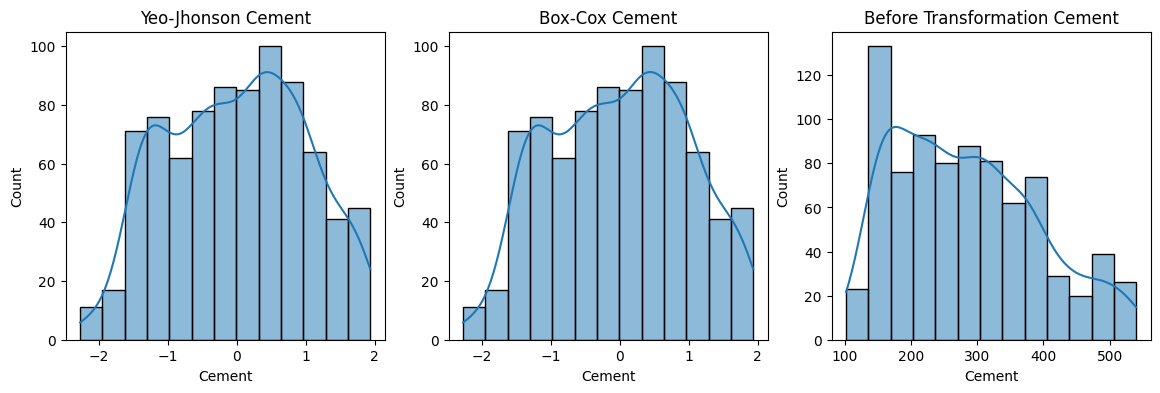

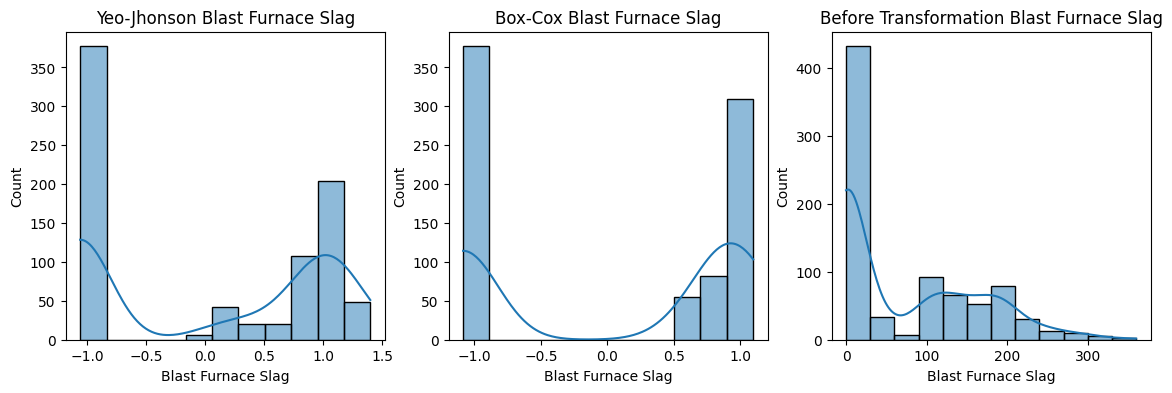

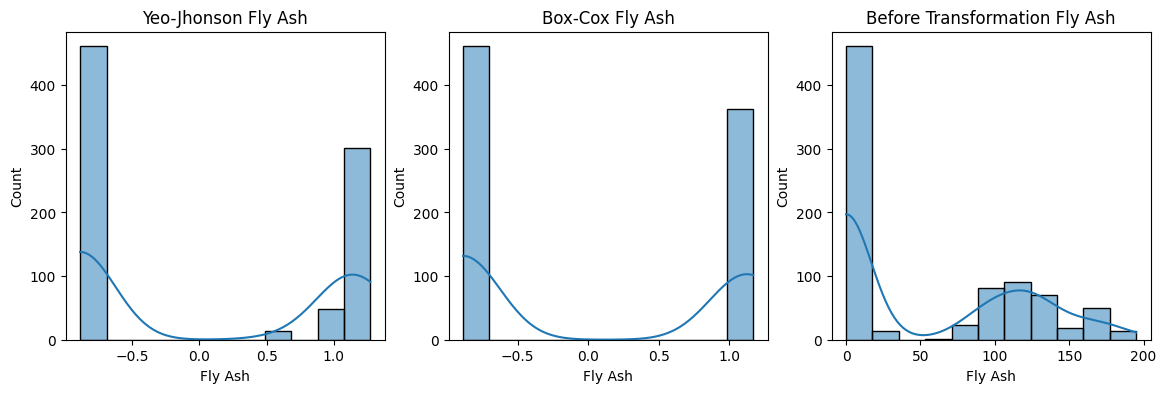

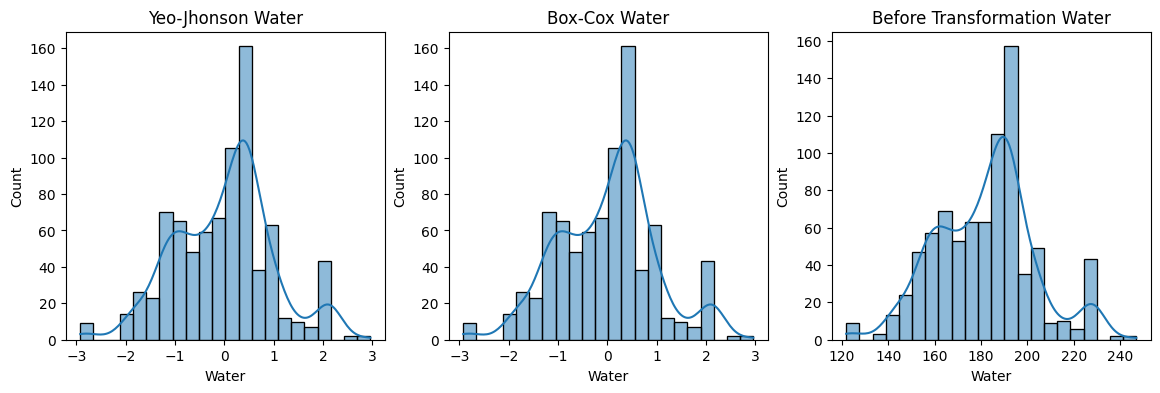

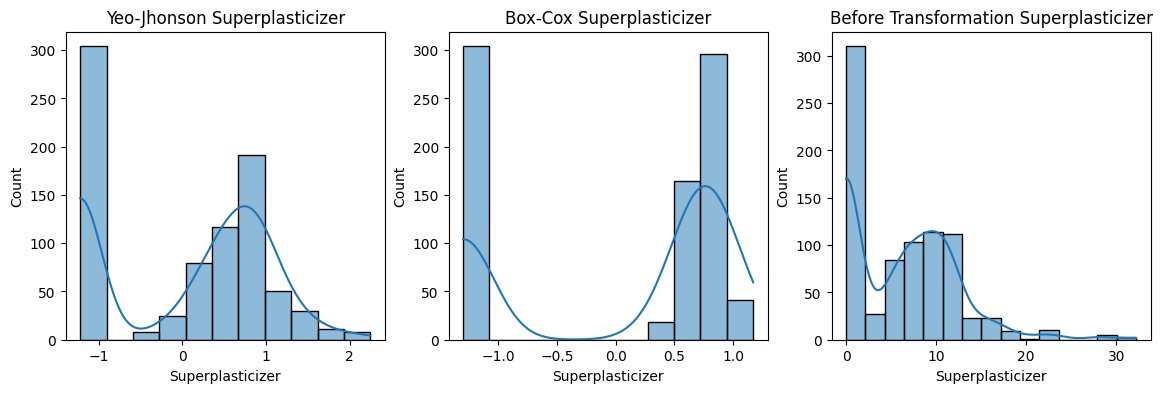

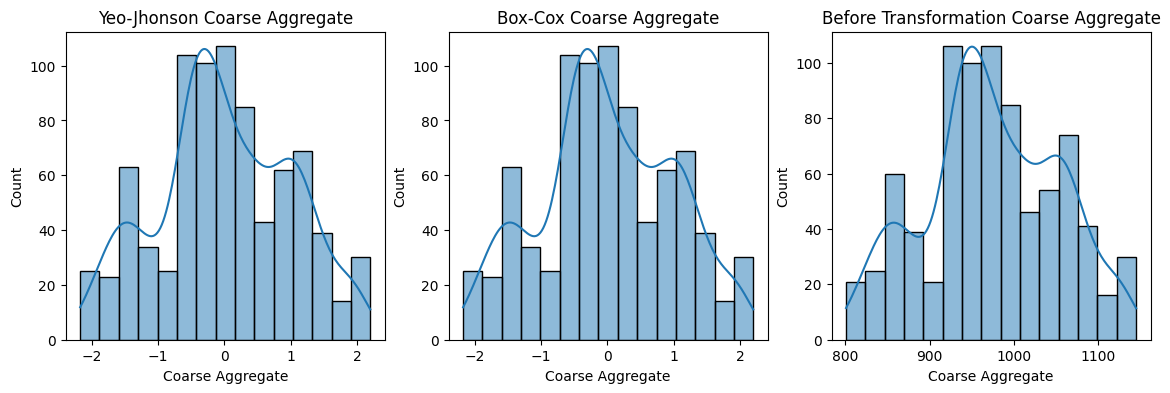

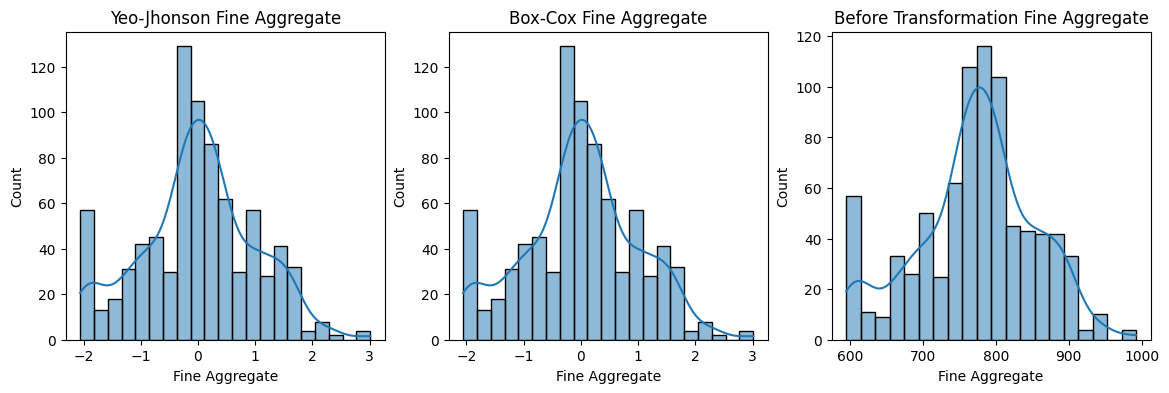

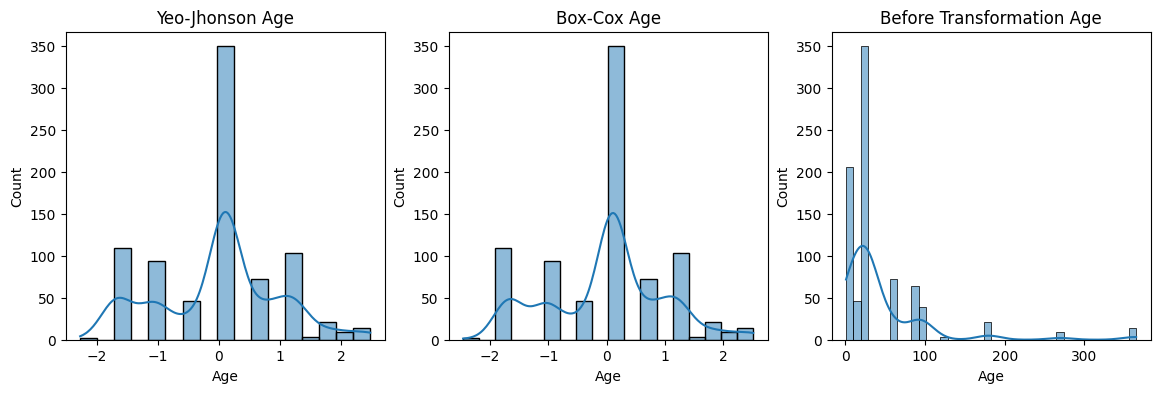

In [67]:
for col in X_train_Yeo_Jhonson.columns:
  plt.figure(figsize=(14,4))
  plt.subplot(131)
  sns.histplot(X_train_Yeo_Jhonson[col], kde=True)
  plt.title(f"Yeo-Jhonson {col}")

  plt.subplot(132)
  sns.histplot(X_train_tranformed_Box_Cox[col],kde=True)
  plt.title(f"Box-Cox {col}")


  plt.subplot(133)
  sns.histplot(X_train[col],kde=True)
  plt.title(f"Before Transformation {col}")

  plt.show()
